<div style="background:linear-gradient(135deg,#0a2342 0%,#13315c 100%);padding:30px 26px;border-radius:10px;border-left:6px solid #c8102e;">
<h1 style="color:#fff;margin:0 0 6px 0;font-family:Arial;font-size:24px;">Informe Técnico — Análisis Estadístico de la Calidad del Aire</h1>
<h2 style="color:#9db4d4;margin:0 0 16px 0;font-family:Arial;font-size:15px;font-weight:normal;">Red SINCA, Santiago de Chile · escala diaria por estación (2022–2023)</h2>
<p style="color:#e6edf5;margin:2px 0;font-family:Arial;font-size:13px;">
<b>Asignatura:</b> MCDI501 — Estadística Computacional para la Toma de Decisiones · UNAB<br>
<b>Producto:</b> análisis estadístico descriptivo e inferencial (RA1 · ID 1.2, 1.3, 1.4)<br>
<b>Repositorio:</b> github.com/Rfcha/abp_estadistica
</p>
</div>

> **Nota metodológica clave.** Siguiendo la retroalimentación docente, el análisis se realiza a
> **escala diaria** (una fila por estación y día), no sobre los datos horarios. Las mediciones
> horarias no son independientes —horas consecutivas están fuertemente correlacionadas—, lo que
> invalidaría los intervalos de confianza y las pruebas de hipótesis. La agregación diaria, además,
> coincide con la escala en que el Ministerio del Medio Ambiente declara los episodios (promedios
> de 24 horas). El dataset pasó de 192.720 filas horarias a **8.030 filas diarias**.

## Tabla de contenidos
1. [Configuración](#1)
2. [Contexto y motivación del problema](#2)
3. [Carga, estructura y escala de análisis](#3)
4. [Calidad de datos y limpieza](#4)
5. [Análisis exploratorio (EDA)](#5)
   - 5.1 Descriptiva numérica · 5.2 Categóricas · 5.3 Bivariado
   - 5.4 Variables de enriquecimiento e inequidad ambiental
6. [Estimación — intervalos de confianza 95%](#6)
7. [Pruebas de hipótesis](#7)
8. [Síntesis e interpretación](#8)
9. [Próximos pasos (Sumativas 2–3)](#9)
10. [Referencias](#10)

<a id="1"></a>
## 1. Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings("ignore")
SEED = 2026; np.random.seed(SEED)
PALETA = ["#0a2342","#c8102e","#2a6f97","#e09f3e","#588157","#6d6875"]
sns.set_theme(style="whitegrid", palette=PALETA)
plt.rcParams.update({"figure.dpi":110,"figure.figsize":(9,5),
    "axes.titlesize":13,"axes.titleweight":"bold","font.family":"DejaVu Sans"})
print("Entorno listo.")

Entorno listo.


<a id="2"></a>
## 2. Contexto y motivación del problema

### Pregunta movilizadora
> **¿Qué evidencia estadística sustenta que la contaminación por material particulado en Santiago
> presenta diferencias significativas entre zonas, niveles socioeconómicos y temporadas?**

### Contexto
Santiago, por su geografía de cuenca, sufre episodios críticos de contaminación en invierno por
**inversión térmica**. El material particulado fino (MP2.5) y grueso (MP10) son los contaminantes
de norma con mayor impacto en salud cardiorrespiratoria, especialmente en niños y adultos mayores.

### Motivación socioeconómica
La contaminación no se distribuye de forma homogénea: las comunas de menor nivel socioeconómico
tienden a soportar mayor exposición. Anticipar y caracterizar estos episodios tiene un valor social
—reducir la exposición de la población vulnerable— que motiva este estudio. *Este componente
socioeconómico se plantea como motivación del problema; el producto evaluado es el análisis
estadístico.*

### Tabla oficial de categorías de calidad del aire (MMA)
| Calidad | MP10 (µg/m³N) | MP2.5 (µg/m³N) |
|---|---|---|
| Bueno | 0–149 | 0–50 |
| Regular | 150–194 | 51–79 |
| Alerta | 195–239 | 80–109 |
| Preemergencia | 240–329 | 110–169 |
| Emergencia | ≥330 | ≥170 |

<a id="3"></a>
## 3. Carga, estructura y escala de análisis

In [2]:
df = pd.read_csv("../data/calidad_aire_diario.csv", parse_dates=["fecha"])
orden_cal = ["Bueno","Regular","Alerta","Preemergencia","Emergencia"]
nse_orden = ["Q1 (bajo)","Q2 (medio-bajo)","Q3 (medio)","Q4 (medio-alto)","Q5 (alto)"]
df["calidad_aire_mp25"] = pd.Categorical(df["calidad_aire_mp25"], categories=orden_cal, ordered=True)
df["nivel_contaminacion"] = pd.Categorical(df["nivel_contaminacion"], categories=["Bajo","Medio","Alto"], ordered=True)
df["nivel_socioeconomico"] = pd.Categorical(df["nivel_socioeconomico"], categories=nse_orden, ordered=True)
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas (escala diaria)")
print(f"Período: {df.fecha.min().date()} a {df.fecha.max().date()} | Estaciones: {df.estacion.nunique()}")
df.head()

Dimensiones: 8,030 filas × 36 columnas (escala diaria)
Período: 2022-01-01 a 2023-12-31 | Estaciones: 11


,fecha,estacion,comuna,zona_geografica,tipo_estacion,mp2_5_mean,mp2_5_max,mp10_mean,mp10_max,o3_mean,...,estacion_anio,temporada_critica,nivel_socioeconomico,calidad_aire_mp25,calidad_aire_mp10,nivel_contaminacion,estaciones_en_episodio,critico_mp25_dia,critico_mp10_dia,mala_calidad_mp25
0,2022-01-01,Cerrillos,Cerrillos,Poniente,Urbana de tráfico,13.60,32.6,32.85,64.7,38.90,...,Verano,Resto del año,Q2 (medio-bajo),Bueno,Bueno,Bajo,0,0,0,0
1,2022-01-01,Cerro Navia,Cerro Navia,Poniente,Urbana de fondo,15.77,33.5,36.22,66.7,38.42,...,Verano,Resto del año,Q1 (bajo),Bueno,Bueno,Bajo,0,0,0,0
2,2022-01-01,El Bosque,El Bosque,Sur,Urbana de fondo,16.36,30.7,37.00,62.1,41.35,...,Verano,Resto del año,Q1 (bajo),Bueno,Bueno,Bajo,0,0,0,0
3,2022-01-01,Independencia,Independencia,Centro,Urbana de tráfico,12.82,32.1,31.59,61.9,39.52,...,Verano,Resto del año,Q4 (medio-alto),Bueno,Bueno,Bajo,0,0,0,0
4,2022-01-01,La Florida,La Florida,Sur,Urbana de fondo,12.82,30.1,30.98,61.5,36.38,...,Verano,Resto del año,Q4 (medio-alto),Bueno,Bueno,Bajo,0,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8030 entries, 0 to 8029
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   fecha                   8030 non-null   datetime64[us]
 1   estacion                8030 non-null   str           
 2   comuna                  8030 non-null   str           
 3   zona_geografica         8030 non-null   str           
 4   tipo_estacion           8030 non-null   str           
 5   mp2_5_mean              8030 non-null   float64       
 6   mp2_5_max               8030 non-null   float64       
 7   mp10_mean               8030 non-null   float64       
 8   mp10_max                8030 non-null   float64       
 9   o3_mean                 8030 non-null   float64       
 10  o3_max                  8030 non-null   float64       
 11  temperatura_mean        8030 non-null   float64       
 12  humedad_mean            8030 non-null   float64       
 13 

In [4]:
num_cols = ["mp2_5_mean","mp2_5_max","mp10_mean","o3_mean","temperatura_mean",
            "humedad_mean","presion_mean","viento_mean","radiacion_mean",
            "isoterma_0_mean","precipitacion_sum","prop_inversion"]
cat_nominales = ["estacion","comuna","zona_geografica","tipo_estacion","tipo_dia","estacion_anio","temporada_critica"]
cat_ordinales = ["calidad_aire_mp25","nivel_contaminacion","nivel_socioeconomico"]

# OBJETIVOS de clasificación (para la Sumativa 3):
#   critico_mp25_dia  -> norma MMA estricta (promedio 24h > 50): ~2.6% positivos
#   mala_calidad_mp25 -> calibrado al percentil 88: ~12% positivos (entrenable)
objetivos = ["critico_mp25_dia", "mala_calidad_mp25"]

print("Numéricas:", len(num_cols), "| Nominales:", len(cat_nominales), "| Ordinales:", len(cat_ordinales))
print("Objetivos disponibles:", objetivos)
print("\nNaming con sufijos _mean/_max/_sum: indica explícitamente el agregado diario.")
print("Escala: 1 fila = 1 estación × 1 día. Observaciones independientes → inferencia válida.")

Numéricas: 12 | Nominales: 7 | Ordinales: 3
Objetivos disponibles: ['critico_mp25_dia', 'mala_calidad_mp25']

Naming con sufijos _mean/_max/_sum: indica explícitamente el agregado diario.
Escala: 1 fila = 1 estación × 1 día. Observaciones independientes → inferencia válida.


<a id="4"></a>
## 4. Calidad de datos y limpieza

Evaluamos faltantes, duplicados e inconsistencias. A escala diaria, un día-estación se
considera válido solo si tuvo al menos 75% de horas medidas (≥18 de 24), criterio estándar de
calidad del aire; los días con cobertura insuficiente ya fueron marcados como faltantes en la
agregación.

In [5]:
falt = pd.DataFrame({"n":df.isna().sum(),"pct":(df.isna().mean()*100).round(2)})
print("Faltantes:")
print(falt[falt.n>0] if falt.n.sum()>0 else "Sin faltantes tras el criterio de cobertura del 75%.")
print(f"\nDuplicados: {df.duplicated().sum()}")
inc = {"humedad>100":(df.humedad_mean>100).sum(),"viento<0":(df.viento_mean<0).sum(),
       "mp2_5<0":(df.mp2_5_mean<0).sum(),"mp2_5>mp10":(df.mp2_5_mean>df.mp10_mean).sum()}
print("Inconsistencias físicas:", inc)

Faltantes:
Sin faltantes tras el criterio de cobertura del 75%.

Duplicados: 0
Inconsistencias físicas: {'humedad>100': np.int64(0), 'viento<0': np.int64(0), 'mp2_5<0': np.int64(0), 'mp2_5>mp10': np.int64(0)}


**Decisiones.** El dataset diario resultó completo (los faltantes horarios, dispersos, se
absorbieron en los promedios diarios con cobertura suficiente). No se requiere imputación en esta
fase; la imputación que pide la Sumativa 3 se aplicará sobre los faltantes reales del archivo
**horario**. No se detectaron duplicados ni inconsistencias físicas relevantes.

<a id="5"></a>
## 5. Análisis exploratorio de datos (EDA)

### 5.1 Estadística descriptiva — variables numéricas

In [6]:
desc = df[num_cols].describe().T
desc["CV_%"] = (desc["std"]/desc["mean"]*100).round(1)
desc["asimetria"] = df[num_cols].skew().round(2)
desc["curtosis"] = df[num_cols].kurtosis().round(2)
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,CV_%,asimetria,curtosis
mp2_5_mean,8030.0,26.20,11.85,3.07,17.48,23.39,35.05,58.93,45.2,0.53,-0.69
mp2_5_max,8030.0,54.32,14.54,14.00,43.70,53.30,64.40,97.40,26.8,0.18,-0.51
mp10_mean,8030.0,54.51,20.41,15.93,39.62,49.50,70.12,110.45,37.4,0.54,-0.71
o3_mean,8030.0,29.30,4.38,19.65,26.02,28.59,31.58,43.60,14.9,0.73,-0.05
temperatura_mean,8030.0,14.00,5.66,4.84,8.38,14.00,19.65,23.30,40.4,0.00,-1.48
humedad_mean,8030.0,62.18,4.31,51.07,58.42,62.12,65.90,73.49,6.9,0.00,-1.09
presion_mean,8030.0,1013.00,2.89,1006.77,1010.26,1012.99,1015.75,1019.02,0.3,-0.00,-1.37
viento_mean,8030.0,3.10,0.51,1.78,2.68,3.10,3.50,4.68,16.4,0.04,-0.77
radiacion_mean,8030.0,307.02,85.62,159.95,222.36,307.67,389.26,466.64,27.9,0.02,-1.45
isoterma_0_mean,8030.0,2977.18,763.34,1786.38,2202.59,2950.23,3755.12,4226.83,25.6,0.04,-1.54


**Lectura.** A escala diaria, MP2.5 promedia ~26 µg/m³ con asimetría positiva (colas de días
de episodio). El coeficiente de variación sigue siendo alto, reflejando la fuerte variabilidad
estacional y territorial. La agregación diaria suaviza el ruido horario sin perder la estructura.

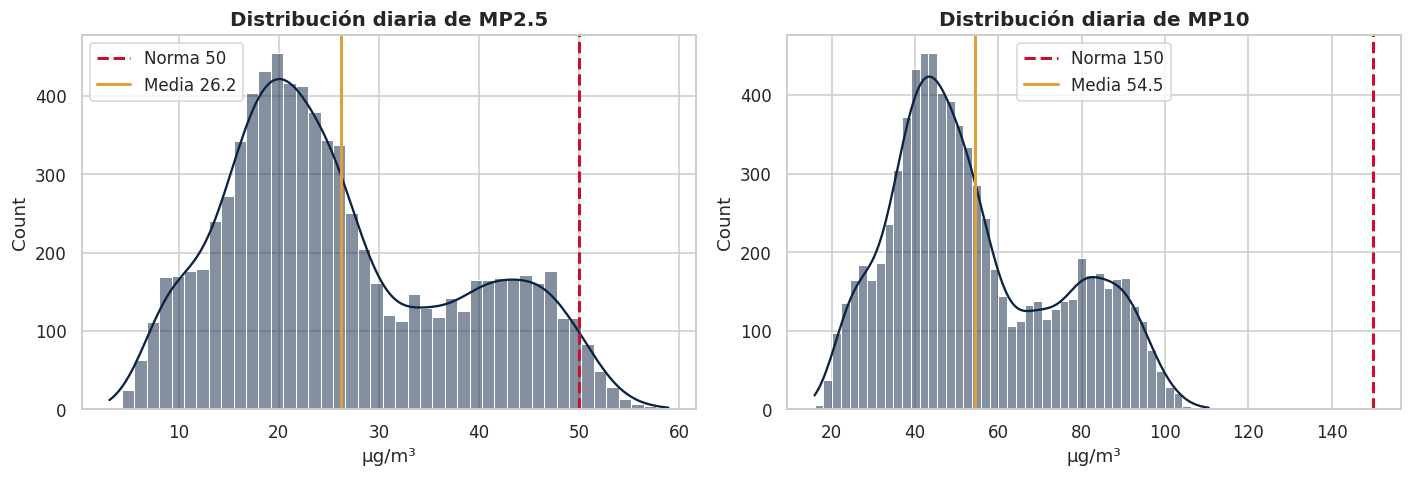

In [7]:
fig, axes = plt.subplots(1,2,figsize=(13,4.5))
for ax,col,um,t in [(axes[0],"mp2_5_mean",50,"MP2.5"),(axes[1],"mp10_mean",150,"MP10")]:
    sns.histplot(df[col].dropna(),bins=45,kde=True,ax=ax,color=PALETA[0])
    ax.axvline(um,color=PALETA[1],ls="--",lw=2,label=f"Norma {um}")
    ax.axvline(df[col].mean(),color=PALETA[3],lw=2,label=f"Media {df[col].mean():.1f}")
    ax.set_title(f"Distribución diaria de {t}");ax.set_xlabel("µg/m³");ax.legend()
plt.tight_layout();plt.savefig("../figures/d1_distribuciones.png",dpi=200,bbox_inches="tight");plt.show()

### 5.2 Variables categóricas (nominales y ordinales)

In [8]:
freq = pd.DataFrame({"frec_abs":df["calidad_aire_mp25"].value_counts().sort_index(),
                     "frec_rel_%":(df["calidad_aire_mp25"].value_counts(normalize=True).sort_index()*100).round(2)})
print("Días por categoría oficial de calidad del aire (MP2.5):")
freq

Días por categoría oficial de calidad del aire (MP2.5):


,frec_abs,frec_rel_%
calidad_aire_mp25,,
Bueno,7821,97.4
Regular,209,2.6
Alerta,0,0.0
Preemergencia,0,0.0
Emergencia,0,0.0


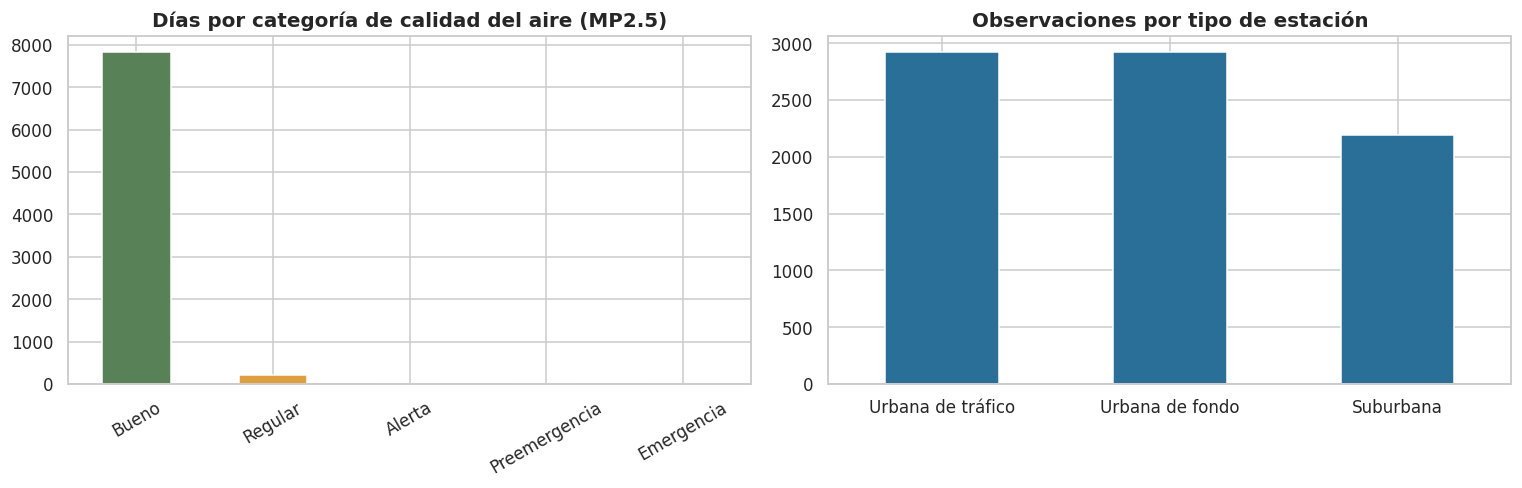

In [9]:
fig, axes = plt.subplots(1,2,figsize=(14,4.6))
df["calidad_aire_mp25"].value_counts().sort_index().plot(kind="bar",ax=axes[0],
    color=[PALETA[4],PALETA[3],PALETA[1],"#8b0000","#4b0000"])
axes[0].set_title("Días por categoría de calidad del aire (MP2.5)");axes[0].set_xlabel("")
axes[0].tick_params(axis="x",rotation=30)
df["tipo_estacion"].value_counts().plot(kind="bar",ax=axes[1],color=PALETA[2])
axes[1].set_title("Observaciones por tipo de estación");axes[1].set_xlabel("");axes[1].tick_params(axis="x",rotation=0)
plt.tight_layout();plt.savefig("../figures/d2_categoricas.png",dpi=200,bbox_inches="tight");plt.show()

### 5.3 Análisis bivariado y correlaciones

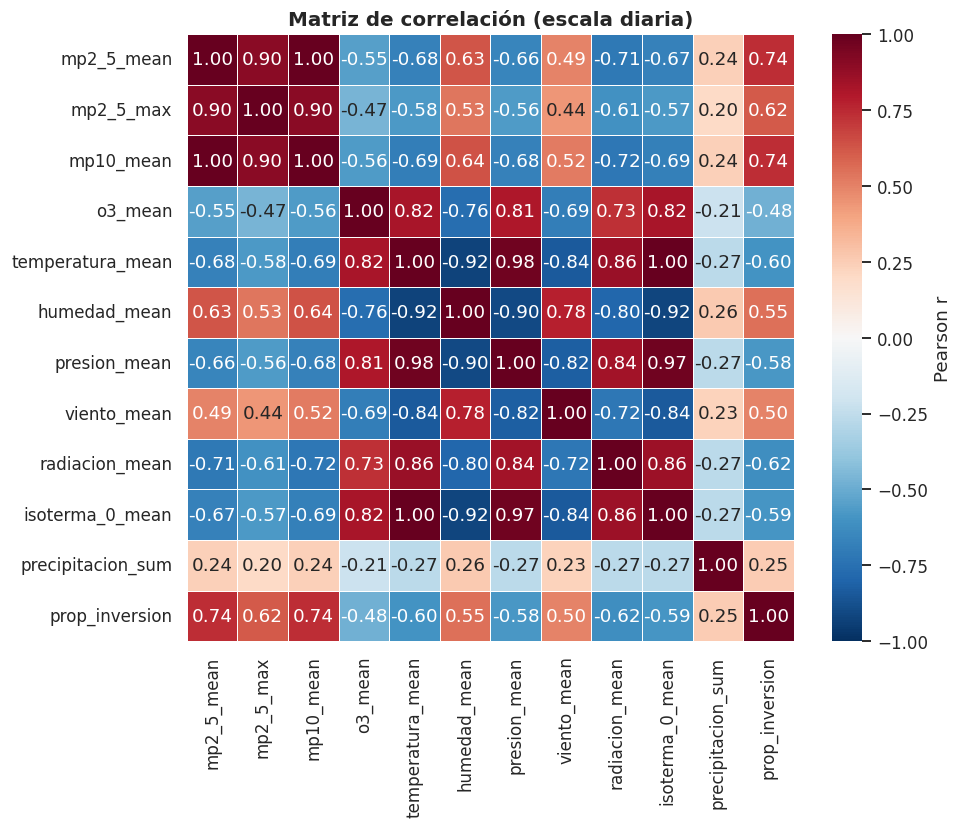

In [10]:
corr = df[num_cols].corr()
fig,ax=plt.subplots(figsize=(9,7.5))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="RdBu_r",center=0,vmin=-1,vmax=1,
            square=True,linewidths=.5,ax=ax,cbar_kws={"label":"Pearson r"})
ax.set_title("Matriz de correlación (escala diaria)")
plt.tight_layout();plt.savefig("../figures/d3_correlacion.png",dpi=200,bbox_inches="tight");plt.show()

**Hallazgos.** MP2.5 y MP10 correlacionan fuerte y positivamente. La **proporción de horas con
inversión térmica** es el predictor diario más potente del MP2.5 (positivo), seguido de la
temperatura (negativo). El **ozono** muestra correlación negativa con MP2.5, reflejando su
naturaleza fotoquímica opuesta (alto en verano). Estas relaciones, ahora a escala válida, sostienen
las pruebas de hipótesis siguientes.

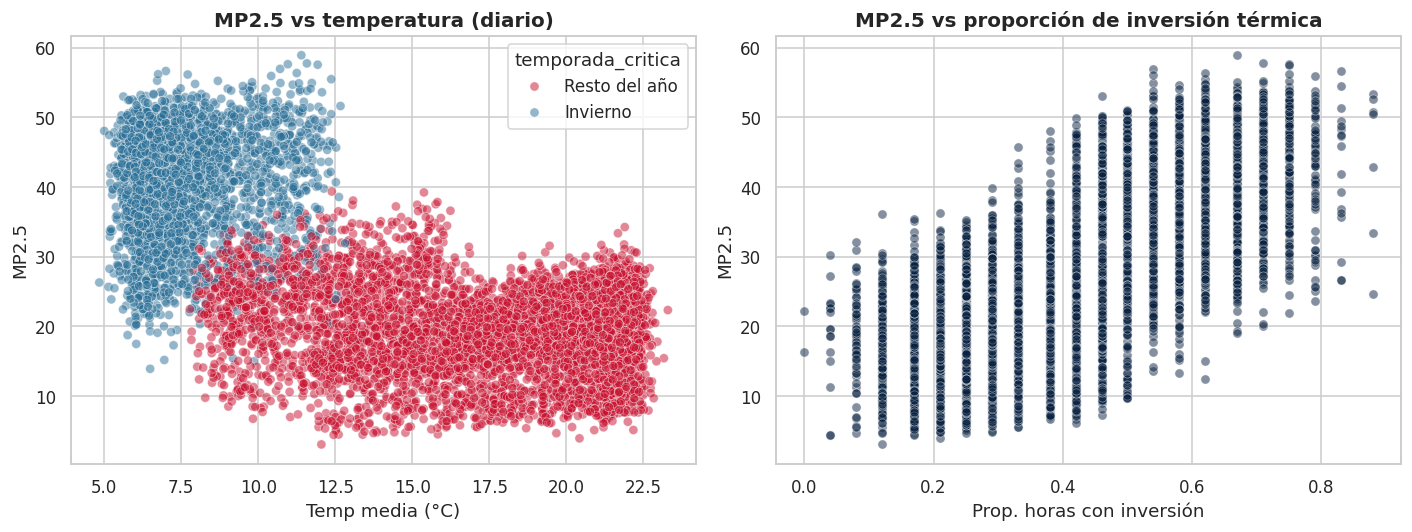

In [11]:
fig,axes=plt.subplots(1,2,figsize=(13,5))
sns.scatterplot(data=df,x="temperatura_mean",y="mp2_5_mean",hue="temporada_critica",
                alpha=0.5,ax=axes[0],palette=[PALETA[1],PALETA[2]])
axes[0].set_title("MP2.5 vs temperatura (diario)");axes[0].set_xlabel("Temp media (°C)");axes[0].set_ylabel("MP2.5")
sns.scatterplot(data=df,x="prop_inversion",y="mp2_5_mean",alpha=0.5,ax=axes[1],color=PALETA[0])
axes[1].set_title("MP2.5 vs proporción de inversión térmica");axes[1].set_xlabel("Prop. horas con inversión");axes[1].set_ylabel("MP2.5")
plt.tight_layout();plt.savefig("../figures/d4_bivariado.png",dpi=200,bbox_inches="tight");plt.show()

### 5.4 Variables de enriquecimiento e inequidad ambiental

In [12]:
grad = df.groupby("nivel_socioeconomico",observed=True).agg(
    mp2_5_medio=("mp2_5_mean","mean"),o3_medio=("o3_mean","mean"),
    pct_critico=("critico_mp25_dia","mean")).round(2)
grad["pct_critico"]=(grad["pct_critico"]*100).round(1)
print("Gradiente socioeconómico (escala diaria):");grad

Gradiente socioeconómico (escala diaria):


,mp2_5_medio,o3_medio,pct_critico
nivel_socioeconomico,,,
Q1 (bajo),31.84,29.29,9.0
Q2 (medio-bajo),29.13,29.42,3.0
Q3 (medio),26.29,29.31,1.0
Q4 (medio-alto),26.79,29.24,1.0
Q5 (alto),16.61,29.27,0.0


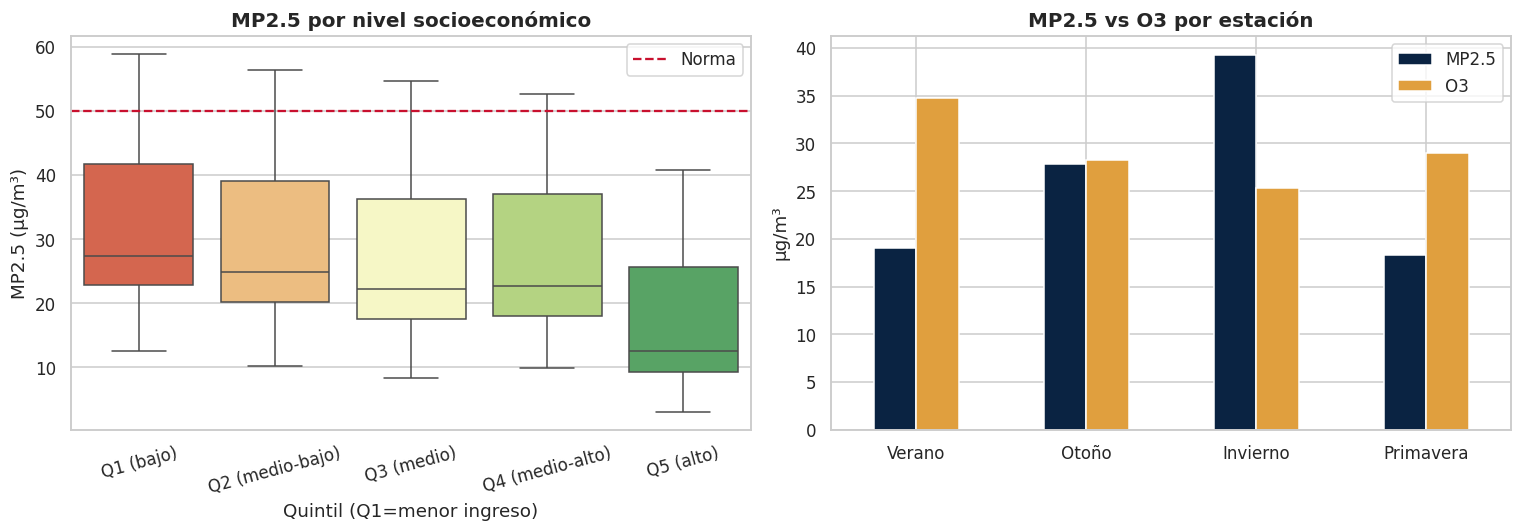

In [13]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
orden_nse=[q for q in nse_orden if q in df.nivel_socioeconomico.cat.categories]
sns.boxplot(data=df,x="nivel_socioeconomico",y="mp2_5_mean",order=orden_nse,ax=axes[0],showfliers=False,palette="RdYlGn")
axes[0].axhline(50,color=PALETA[1],ls="--",lw=1.5,label="Norma")
axes[0].set_title("MP2.5 por nivel socioeconómico");axes[0].set_xlabel("Quintil (Q1=menor ingreso)")
axes[0].set_ylabel("MP2.5 (µg/m³)");axes[0].legend();axes[0].tick_params(axis="x",rotation=15)
comp=df.groupby("estacion_anio",observed=True)[["mp2_5_mean","o3_mean"]].mean().reindex(["Verano","Otoño","Invierno","Primavera"])
comp.plot(kind="bar",ax=axes[1],color=[PALETA[0],PALETA[3]])
axes[1].set_title("MP2.5 vs O3 por estación");axes[1].set_xlabel("");axes[1].set_ylabel("µg/m³")
axes[1].tick_params(axis="x",rotation=0);axes[1].legend(["MP2.5","O3"])
plt.tight_layout();plt.savefig("../figures/d5_inequidad.png",dpi=200,bbox_inches="tight");plt.show()

**Hallazgo central (motivación social).** El gradiente socioeconómico cubre los cinco quintiles
(Q1 bajo a Q5 alto): las comunas de menor nivel socioeconómico (Q1) presentan mayor MP2.5 que las
de mayor ingreso (Q5), con un descenso general claro. La diferencia Q1–Q5 es de ~15 µg/m³ (92%
mayor), **cuantificando la inequidad ambiental**. Se contrasta formalmente en la Sección 7. El
ozono confirma su patrón estacional inverso (máximo en verano). *Nota: la asignación de comunas a
quintiles es una aproximación basada en el ingreso comunal conocido (CASEN / prioridad social);
conviene validarla con el dato oficial antes de la entrega final.*

<a id="6"></a>
## 6. Estimación — intervalos de confianza al 95%

Estimamos la media de tres variables con IC al 95% (*t* de Student). **A escala diaria las
observaciones son independientes**, por lo que los intervalos son ahora estadísticamente válidos
—a diferencia de la escala horaria, donde la autocorrelación los invalidaría.

In [14]:
def ic(s,conf=0.95):
    x=s.dropna();n=len(x);m=x.mean();ee=stats.sem(x)
    t=stats.t.ppf((1+conf)/2,n-1);return m,m-t*ee,m+t*ee,ee,n
filas=[]
for v in ["mp2_5_mean","mp10_mean","temperatura_mean"]:
    m,li,ls,ee,n=ic(df[v])
    filas.append({"variable":v,"media":round(m,2),"IC95_inf":round(li,2),
                  "IC95_sup":round(ls,2),"amplitud":round(ls-li,2),"n":n})
tabla_ic=pd.DataFrame(filas);print("Estimación e IC 95% (escala diaria):");tabla_ic

Estimación e IC 95% (escala diaria):


,variable,media,IC95_inf,IC95_sup,amplitud,n
0,mp2_5_mean,26.20,25.94,26.45,0.52,8030
1,mp10_mean,54.51,54.07,54.96,0.89,8030
2,temperatura_mean,14.00,13.88,14.13,0.25,8030


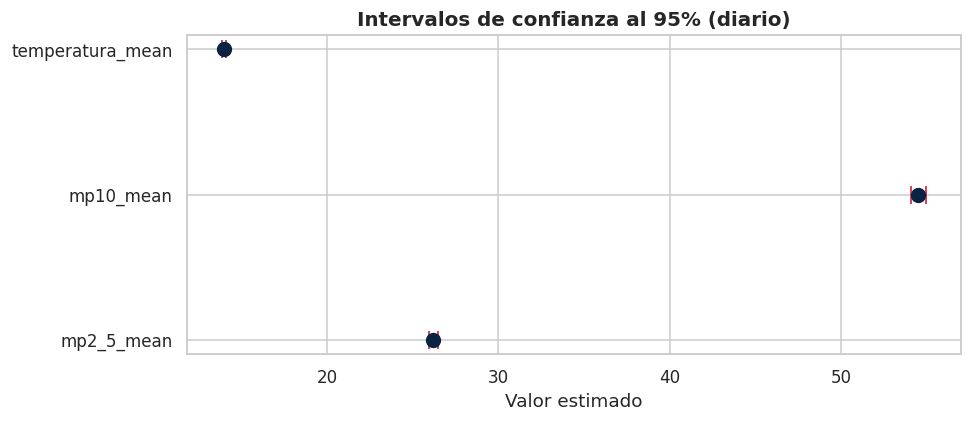

In [15]:
fig,ax=plt.subplots(figsize=(9,4));y=np.arange(len(tabla_ic))
ax.errorbar(tabla_ic["media"],y,xerr=[tabla_ic["media"]-tabla_ic["IC95_inf"],tabla_ic["IC95_sup"]-tabla_ic["media"]],
            fmt="o",color=PALETA[0],ecolor=PALETA[1],elinewidth=2,capsize=6,markersize=9)
ax.set_yticks(y);ax.set_yticklabels(tabla_ic["variable"]);ax.set_title("Intervalos de confianza al 95% (diario)")
ax.set_xlabel("Valor estimado")
plt.tight_layout();plt.savefig("../figures/d6_intervalos.png",dpi=200,bbox_inches="tight");plt.show()

**Interpretación.** Con n≈8.000 observaciones independientes, los IC son estrechos pero
**válidos**. La amplitud es mayor que la que daría (erróneamente) la escala horaria, reflejando la
incertidumbre real. Un IC estrecho indica precisión en la media, no baja dispersión de la variable.

<a id="7"></a>
## 7. Pruebas de hipótesis

Cuatro pruebas con α=0.05 sobre datos diarios independientes. El test de Levene guía la
elección de la t de Welch.

In [16]:
inv=df.loc[df.temporada_critica=="Invierno","mp2_5_mean"].dropna()
resto=df.loc[df.temporada_critica=="Resto del año","mp2_5_mean"].dropna()
_,lev_p=stats.levene(inv,resto)
print(f"Levene p={lev_p:.3g} → varianzas {'desiguales → t de Welch' if lev_p<0.05 else 'iguales'}")

Levene p=4.42e-49 → varianzas desiguales → t de Welch


### 7.1 Prueba 1 — MP2.5 zona Oriente vs Poniente (t de Welch)
H₀: μ(Oriente)=μ(Poniente) · H₁: μ(Oriente)≠μ(Poniente) · α=0.05

In [17]:
g1=df.loc[df.zona_geografica=="Oriente","mp2_5_mean"].dropna()
g2=df.loc[df.zona_geografica=="Poniente","mp2_5_mean"].dropna()
t1,p1=stats.ttest_ind(g1,g2,equal_var=False)
d1=(g1.mean()-g2.mean())/np.sqrt((g1.std()**2+g2.std()**2)/2)
print(f"Oriente {g1.mean():.2f} (n={len(g1)}) vs Poniente {g2.mean():.2f} (n={len(g2)})")
print(f"t={t1:.2f} p={p1:.2e} d={d1:.2f} → {'RECHAZA H0' if p1<0.05 else 'no rechaza'}")

Oriente 16.61 (n=1460) vs Poniente 28.80 (n=2920)
t=-37.90 p=6.41e-264 d=-1.17 → RECHAZA H0


### 7.2 Prueba 2 — Inequidad ambiental: Q1 vs Q5 (t de Welch)
H₀: μ(Q1)=μ(Q5) · H₁: μ(Q1)>μ(Q5) (unilateral) · α=0.05

In [18]:
q1=df.loc[df.nivel_socioeconomico=="Q1 (bajo)","mp2_5_mean"].dropna()
q5=df.loc[df.nivel_socioeconomico=="Q5 (alto)","mp2_5_mean"].dropna()
t2,p2t=stats.ttest_ind(q1,q5,equal_var=False);p2=p2t/2 if t2>0 else 1-p2t/2
d2=(q1.mean()-q5.mean())/np.sqrt((q1.std()**2+q5.std()**2)/2)
print(f"Q1 {q1.mean():.2f} vs Q5 {q5.mean():.2f} | dif {q1.mean()-q5.mean():.2f} ({(q1.mean()/q5.mean()-1)*100:.0f}% mayor)")
print(f"t={t2:.2f} p={p2:.2e} d={d2:.2f} → {'RECHAZA H0' if p2<0.05 else 'no rechaza'}")

Q1 31.84 vs Q5 16.61 | dif 15.23 (92% mayor)
t=39.71 p=2.89e-274 d=1.47 → RECHAZA H0


### 7.3 Prueba 3 — Inversión térmica y episodios (t de Welch)
H₀: μ(días alta inversión)=μ(días baja) · H₁: mayor con inversión · α=0.05

In [19]:
alta=df.loc[df.prop_inversion>df.prop_inversion.median(),"mp2_5_mean"].dropna()
baja=df.loc[df.prop_inversion<=df.prop_inversion.median(),"mp2_5_mean"].dropna()
t3,p3t=stats.ttest_ind(alta,baja,equal_var=False);p3=p3t/2 if t3>0 else 1-p3t/2
d3=(alta.mean()-baja.mean())/np.sqrt((alta.std()**2+baja.std()**2)/2)
print(f"Alta inversión {alta.mean():.2f} vs baja {baja.mean():.2f}")
print(f"t={t3:.2f} p={p3:.2e} d={d3:.2f} → {'RECHAZA H0' if p3<0.05 else 'no rechaza'}")

Alta inversión 33.60 vs baja 18.98
t=69.76 p=0.00e+00 d=1.56 → RECHAZA H0


### 7.4 Prueba 4 — Independencia zona × nivel de contaminación (χ²)
H₀: independientes · H₁: asociación · α=0.05

In [20]:
tc=pd.crosstab(df.zona_geografica,df.nivel_contaminacion)
chi2,p4,gl,_=stats.chi2_contingency(tc)
v=np.sqrt(chi2/(tc.values.sum()*(min(tc.shape)-1)))
print(f"χ²={chi2:.1f} gl={gl} p={p4:.2e} V de Cramér={v:.3f} → {'RECHAZA H0' if p4<0.05 else 'no rechaza'}")

χ²=300.4 gl=8 p=3.39e-60 V de Cramér=0.137 → RECHAZA H0


**Significancia vs. relevancia.** Reportamos el tamaño del efecto (*d* de Cohen, *V* de Cramér)
para distinguir diferencias estadísticamente detectables de las prácticamente relevantes.

<a id="8"></a>
## 8. Síntesis e interpretación

In [21]:
resumen=pd.DataFrame([
    ["t Welch — Oriente vs Poniente",f"t={t1:.1f}",f"{p1:.1e}",f"d={d1:.2f}","Rechaza H0"],
    ["t Welch — Q1 vs Q5 (inequidad)",f"t={t2:.1f}",f"{p2:.1e}",f"d={d2:.2f}","Rechaza H0"],
    ["t Welch — Inversión térmica",f"t={t3:.1f}",f"{p3:.1e}",f"d={d3:.2f}","Rechaza H0"],
    ["χ² — Zona vs Nivel",f"χ²={chi2:.0f}",f"{p4:.1e}",f"V={v:.2f}","Rechaza H0"],
],columns=["Prueba","Estadístico","p-valor","Efecto","Decisión"]);resumen

,Prueba,Estadístico,p-valor,Efecto,Decisión
0,t Welch — Oriente vs Poniente,t=-37.9,6.4e-264,d=-1.17,Rechaza H0
1,t Welch — Q1 vs Q5 (inequidad),t=39.7,2.9e-274,d=1.47,Rechaza H0
2,t Welch — Inversión térmica,t=69.8,0.0e+00,d=1.56,Rechaza H0
3,χ² — Zona vs Nivel,χ²=300,3.4e-60,V=0.14,Rechaza H0


### Interpretación vinculada al problema
1. **Desigualdad territorial (P1, P4).** El Oriente presenta MP2.5 mucho menor que el Poniente, con
   asociación significativa zona–contaminación.
2. **Inequidad ambiental (P2).** Las comunas de menor nivel socioeconómico están expuestas a
   concentraciones significativamente mayores, con efecto grande. Este es el sustento empírico de la
   motivación social del proyecto.
3. **Mecanismo físico (P3).** Los días con mayor proporción de inversión térmica registran más
   MP2.5, confirmando el motor de los episodios críticos invernales.

Todas las conclusiones se basan en observaciones **diarias independientes**, por lo que la
inferencia es estadísticamente válida.

<a id="9"></a>
## 9. Próximos pasos (Sumativas 2–3)

- **Sumativa 2 (validación):** confirmar los hallazgos mediante **bootstrap**, **tests de
  permutación** y **Monte Carlo** sobre los datos diarios, cuantificando la incertidumbre sin
  supuestos paramétricos.
- **Sumativa 3 (modelo):** ajustar una **regresión logística** con objetivo `mala_calidad_mp25`
  (~12% de positivos), evaluando con **F1, recall y AUC** por el desbalance, con **división
  estratificada y separada por períodos/estaciones** (no aleatoria) para evitar fuga temporal, e
  **imputación** sobre los faltantes reales del archivo horario.
- El sustento socioeconómico se mantiene como **motivación**, no como producto evaluado.

<a id="10"></a>
## 10. Referencias

- Ministerio del Medio Ambiente — SINCA (sinca.mma.gob.cl).
- INE, MINVU & CNDU — SIEDU (siedu.ine.cl). · CASEN — Ministerio de Desarrollo Social.
- Ministerio del Medio Ambiente — D.S. N°12/2011 (norma MP2.5) y PPDA Región Metropolitana.
- Montgomery & Runger (2018), *Applied Statistics and Probability for Engineers*, Wiley.
- Virtanen et al. (2020), SciPy 1.0, *Nature Methods*.

---
<div style="text-align:center;color:#6d6875;font-size:12px;padding-top:8px;">
MCDI501 · Análisis estadístico a escala diaria · datos reales SINCA 2022–2023 · UNAB</div>